In [26]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[1, 4], [1, 3], [0, 4], [5, 1], [6, 2], [4, 0]])

In [27]:
def draw_plot_notation():
  for i, (x, y) in enumerate(X, start=1):
    plt.text(x + 0.1, y + 0.05, str(i))

def draw_plot(colors, datas):
  plt.figure(figsize=(6, 6))
  for cluster in [0, 1]:
    points = X[datas == cluster]
    plt.scatter(points[:, 0], points[:, 1], c=colors[cluster], label=f"Cluster {cluster}")
  draw_plot_notation()

## (a) Plot the observations.

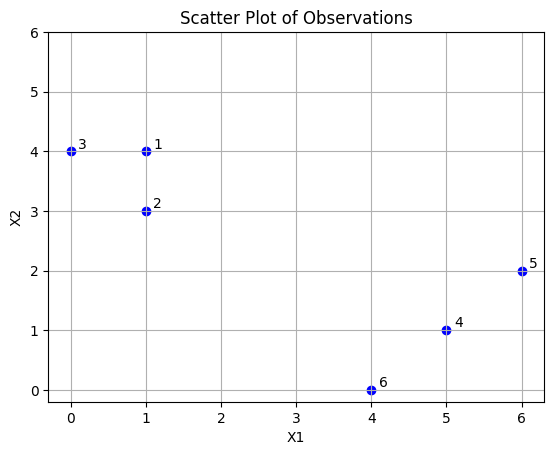

In [28]:
plt.scatter(X[:, 0], X[:, 1], color="blue", marker="o")

for i, (x, y) in enumerate(X, start=1):
    plt.text(x + 0.1, y + 0.05, str(i))


plt.xlabel("X1")
plt.ylabel("X2")
plt.xticks(np.arange(0, 7, 1))
plt.yticks(np.arange(0, 7, 1))
plt.title("Scatter Plot of Observations")
plt.grid(True)
plt.show()

## (b)  Randomly assign a cluster label to each observation. You can use the np.random.choice() function to do this. Report the cluster labels for each observation.

In [29]:
np.random.seed(201)
labels = np.random.choice([0, 1], size=len(X))

for i, label in enumerate(labels, start=1):
    print(f"Observation {i}: Cluster {label}")

Observation 1: Cluster 0
Observation 2: Cluster 1
Observation 3: Cluster 0
Observation 4: Cluster 1
Observation 5: Cluster 0
Observation 6: Cluster 1


## (c) Compute the centroid for each cluster.

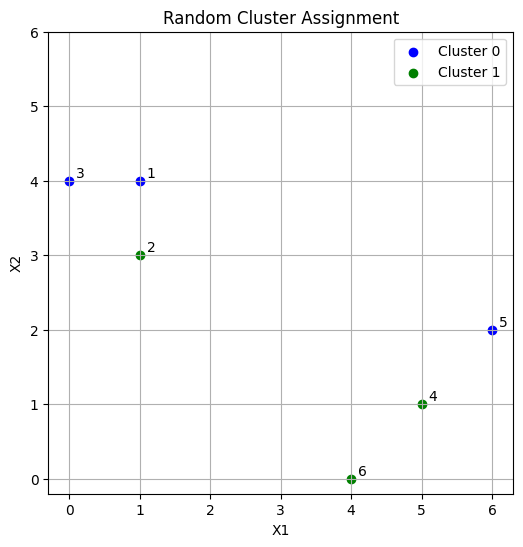

In [30]:
colors = ['blue', 'green']
draw_plot(colors, labels)

plt.xlabel("X1")
plt.ylabel("X2")
plt.xticks(np.arange(0, 7, 1))
plt.yticks(np.arange(0, 7, 1))
plt.title("Random Cluster Assignment")
plt.legend()
plt.grid(True)
plt.show()

## (d) Assign each observation to the centroid to which it is closest, in terms of Euclidean distance. Report the cluster labels for each observation.



Centroids:
Cluster 0: [2.33333333 3.33333333]
Cluster 1: [3.33333333 1.33333333]


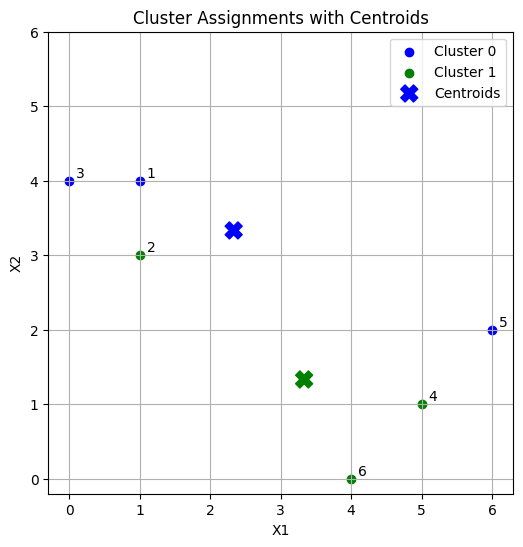

In [31]:
centroids = np.array([X[labels == k].mean(axis=0) for k in [0, 1]])
print("\nCentroids:")
for k, centroid in enumerate(centroids):
    print(f"Cluster {k}: {centroid}")

draw_plot(colors, labels)

plt.scatter(centroids[:, 0], centroids[:, 1], c=colors, marker='X', s=150, label='Centroids')

plt.xlabel("X1")
plt.ylabel("X2")
plt.xticks(np.arange(0, 7, 1))
plt.yticks(np.arange(0, 7, 1))
plt.title("Cluster Assignments with Centroids")
plt.legend()
plt.grid(True)
plt.show()

## (e)  Repeat (c) and (d) until the answers obtained stop changing.


Re-assigned Cluster Labels:
Observation 1: Cluster 0
Observation 2: Cluster 0
Observation 3: Cluster 0
Observation 4: Cluster 1
Observation 5: Cluster 1
Observation 6: Cluster 1


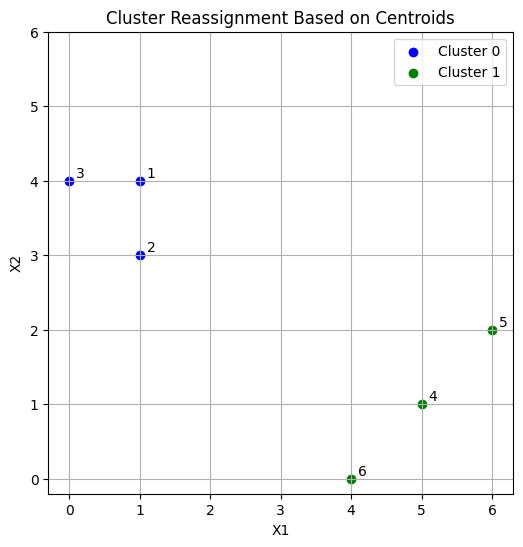

In [32]:
distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
new_labels = np.argmin(distances, axis=1)

print("\nRe-assigned Cluster Labels:")
for i, label in enumerate(new_labels, start=1):
    print(f"Observation {i}: Cluster {label}")

draw_plot(colors, new_labels)

plt.xlabel("X1")
plt.ylabel("X2")
plt.xticks(np.arange(0, 7, 1))
plt.yticks(np.arange(0, 7, 1))
plt.title("Cluster Reassignment Based on Centroids")
plt.legend()
plt.grid(True)
plt.show()

## (e) In your plot from (a), color the observations according to the cluster labels obtained.


Iteration 1：
Cluster 0: [(1, 4), (0, 4), (6, 2)]
Cluster 1: [(1, 3), (5, 1), (4, 0)]


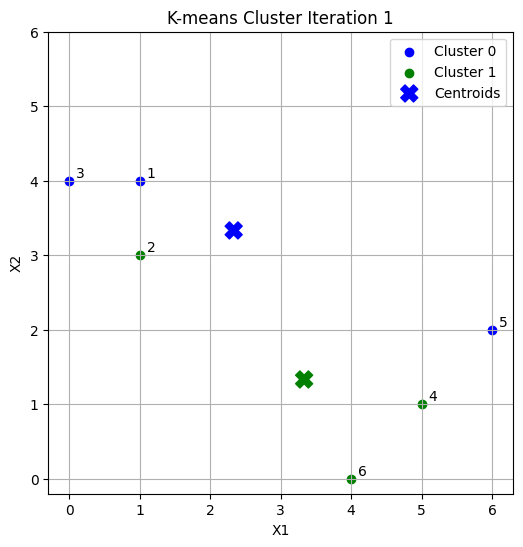


Iteration 2：
Cluster 0: [(1, 4), (1, 3), (0, 4)]
Cluster 1: [(5, 1), (6, 2), (4, 0)]


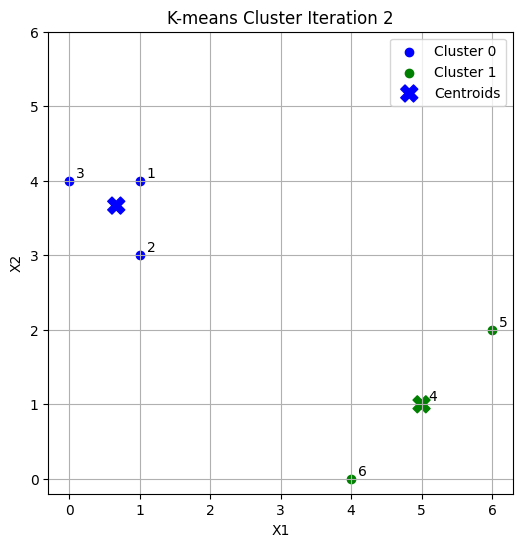


Converged at iteration 2

Centroids:
Cluster 0: [0.66666667 3.66666667]
Cluster 1: [5. 1.]

Final Cluster Labels:
Observation 1: Cluster 0
Observation 2: Cluster 1
Observation 3: Cluster 0
Observation 4: Cluster 1
Observation 5: Cluster 0
Observation 6: Cluster 1


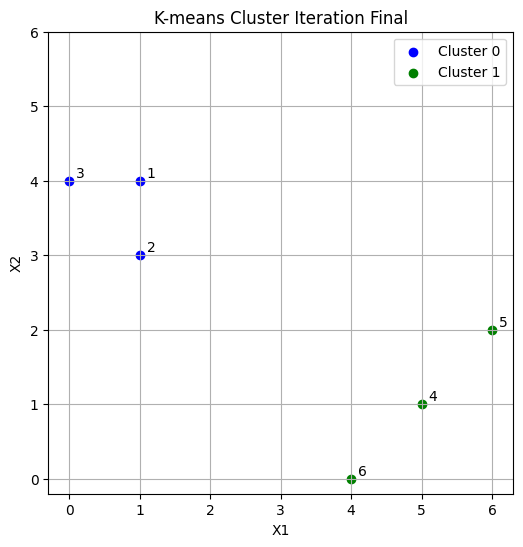

In [33]:
iteration = 1
itr_labels = labels

while True:
    print(f"\nIteration {iteration}：")
    for k in [0, 1]:
        points_in_cluster = X[itr_labels == k]
        # Convert numpy integers to standard python integers for printing
        points_list = [(int(x), int(y)) for x, y in points_in_cluster]
        print(f"Cluster {k}: {points_list}")

    # Compute centroids
    centroids = np.array([X[itr_labels == k].mean(axis=0) for k in [0, 1]])

    # Plot current state
    draw_plot(colors, itr_labels)

    plt.scatter(centroids[:, 0], centroids[:, 1], c=colors, marker='X', s=150, label='Centroids')
    plt.title(f"K-means Cluster Iteration {iteration}")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.xticks(np.arange(0, 7, 1))
    plt.yticks(np.arange(0, 7, 1))
    plt.legend()
    plt.grid(True)
    plt.show()

    # Assign clusters based on closest centroid
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    new_labels = np.argmin(distances, axis=1)

    # Check convergence
    if np.all(new_labels == itr_labels):
        print(f"\nConverged at iteration {iteration}")
        break

    itr_labels = new_labels
    iteration += 1

print("\nCentroids:")
for k, c in enumerate(centroids):
    print(f"Cluster {k}: {c}")

# Final results
print("\nFinal Cluster Labels:")
for i, label in enumerate(labels, start=1):
    print(f"Observation {i}: Cluster {label}")

draw_plot(colors, itr_labels)

plt.title(f"K-means Cluster Iteration Final")
plt.xlabel("X1")
plt.ylabel("X2")
plt.xticks(np.arange(0, 7, 1))
plt.yticks(np.arange(0, 7, 1))
plt.legend()
plt.grid(True)
plt.show()